# 05 — Valor del contrato, precio base y segmentacion por cuantia

**Proposito.** Resolver o cerrar el insight N-K05, objetivo analitico numero uno de este EDA: por que el
sobrecosto medido con `valor_pagado` es del 0,1% cuando el planteamiento del problema del anteproyecto
afirma que aproximadamente uno de cada cuatro contratos termina costando mas de lo presupuestado. Y
cerrar la brecha 3: la cuantia inicial es variable independiente declarada en el numeral 3.3 del
anteproyecto y hasta ahora no se habia segmentado.

**Insumo.** `data/universo_extendido.parquet` (notebook 01) y `data/marcas_calidad.parquet` (notebook 02,
marca `precio_base_valido`).

**Etiquetas de objetivo que atiende:** `[A-OE03]`, `[A-OE04]`, `[A-H1]`, `[B-OE2]`,
`[B-OE3-insumo]`, `[CALIDAD]`.

**Las cuatro magnitudes monetarias disponibles y lo que significa cada una.**

| Campo | Fuente | Momento del ciclo | Interpretacion |
|---|---|---|---|
| `precio_base` | proceso | antes de la adjudicacion | presupuesto oficial estimado por la entidad |
| `valor_total_adjudicacion` | proceso | en la adjudicacion | valor por el que se adjudico el proceso |
| `valor_del_contrato` | contrato | vigente al momento de la extraccion | valor contractual actual |
| `valor_pagado` | contrato | ejecucion | pagos reportados |

La hipotesis N-K05 sostiene que `valor_del_contrato` no es el valor inicial pactado sino el valor
actualizado tras adiciones. Si es cierta, comparar `valor_pagado` contra `valor_del_contrato` no puede
detectar sobrecosto por construccion, y el sobrecosto real debe aparecer al comparar
`valor_del_contrato` contra `precio_base` o contra `valor_total_adjudicacion`.

In [1]:
import sys
from pathlib import Path

_p = Path.cwd()
BASE_EDA = _p.parent if _p.name == "notebooks" else _p
sys.path.insert(0, str(BASE_EDA / "src"))

import numpy as np
import pandas as pd
from scipy import stats
from eda_comun import *

plt, CMAP_SEQ, CMAP_DIV = configurar_matplotlib()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Modulo propio eda_comun cargado desde:", BASE_EDA / "src")
print("Alfa declarado a priori:", ALFA)

Modulo propio eda_comun cargado desde: /home/william-telles/Documentos/extraccion-datos-secop2-main (1)/extraccion-datos-secop2-main/eda-extendido-integral/src
Alfa declarado a priori: 0.05


In [2]:
df = pd.read_parquet(DIR_DATA / "universo_extendido.parquet")
marcas = pd.read_parquet(DIR_DATA / "marcas_calidad.parquet")
df = df.merge(marcas, on="id_contrato", how="left")
assert len(df) == N_UNIVERSO_ESPERADO
df["licitacion_publica"] = es_licitacion_publica(df["modalidad_de_contratacion"])

# Contratos por portafolio: el contraste limpio exige un unico contrato por proceso
cpp = df.groupby("proceso_de_compra")["id_contrato"].transform("size")
df["n_contratos_del_portafolio"] = cpp
print(f"Universo: {len(df):,} | Observable: {int(df['observable'].sum()):,}")
print(f"Contratos cuyo portafolio tiene un unico contrato: {int((cpp == 1).sum()):,} "
      f"({(cpp == 1).mean()*100:.1f}%)")
print(f"precio_base utilizable (0 < pb <= 1e13): {int(df['precio_base_valido'].sum()):,}")

Universo: 48,331 | Observable: 19,194
Contratos cuyo portafolio tiene un unico contrato: 40,534 (83.9%)
precio_base utilizable (0 < pb <= 1e13): 47,704


## 1. Depuracion de las magnitudes del proceso

In [3]:
marcar("depuracion")

df["adjudicado_valido"] = (df["valor_adjudicado_proceso"] > 0) & (df["valor_adjudicado_proceso"] <= 1e13)

dep = pd.DataFrame({
    "magnitud": ["precio_base", "valor_adjudicado_proceso", "valor_del_contrato", "valor_pagado"],
    "n_no_nulo": [int(df[c].notna().sum()) for c in
                  ["precio_base", "valor_adjudicado_proceso", "valor_del_contrato", "valor_pagado"]],
    "n_mayor_cero": [int((df[c] > 0).sum()) for c in
                     ["precio_base", "valor_adjudicado_proceso", "valor_del_contrato", "valor_pagado"]],
    "n_utilizable": [int(df["precio_base_valido"].sum()), int(df["adjudicado_valido"].sum()),
                     int((df["valor_del_contrato"] > 0).sum()), int((df["valor_pagado"] > 0).sum())],
    "mediana_utilizable": [
        df.loc[df["precio_base_valido"], "precio_base"].median(),
        df.loc[df["adjudicado_valido"], "valor_adjudicado_proceso"].median(),
        df.loc[df["valor_del_contrato"] > 0, "valor_del_contrato"].median(),
        df.loc[df["valor_pagado"] > 0, "valor_pagado"].median()],
})
dep["cobertura_pct"] = (dep["n_utilizable"] / len(df) * 100).round(2)
dep

,magnitud,n_no_nulo,n_mayor_cero,n_utilizable,mediana_utilizable,cobertura_pct
0,precio_base,48293,47705,47704,"205,000,000.0000",98.7000
1,valor_adjudicado_proceso,48293,35361,35354,"250,573,894.0000",73.1500
2,valor_del_contrato,48331,47635,47635,"206,071,581.0000",98.5600
3,valor_pagado,48331,15035,15035,"162,475,966.0000",31.1100


## 2. Correlacion entre las cuatro magnitudes

In [4]:
marcar("corr_valores")

cols = ["precio_base", "valor_adjudicado_proceso", "valor_del_contrato", "valor_pagado"]
base_corr = df[df["precio_base_valido"] & df["adjudicado_valido"] &
               (df["valor_del_contrato"] > 0) & (df["valor_pagado"] > 0)][cols]
print(f"N efectivo con las cuatro magnitudes utilizables: {len(base_corr):,}")
m = base_corr.corr(method="spearman").round(3)
print()
print(m.to_string())
print()
print("Asimetria (skew) de cada magnitud, que justifica el uso de Spearman y no Pearson:")
print(df[cols].skew().round(2).to_string())

N efectivo con las cuatro magnitudes utilizables: 10,886

                          precio_base  valor_adjudicado_proceso  valor_del_contrato  valor_pagado
precio_base                    1.0000                    0.9900              0.9890        0.9580
valor_adjudicado_proceso       0.9900                    1.0000              0.9930        0.9640
valor_del_contrato             0.9890                    0.9930              1.0000        0.9710
valor_pagado                   0.9580                    0.9640              0.9710        1.0000

Asimetria (skew) de cada magnitud, que justifica el uso de Spearman y no Pearson:
precio_base                 94.5600
valor_adjudicado_proceso   138.6900
valor_del_contrato         112.0600
valor_pagado                64.2300


## 3. Resolucion de N-K05: `valor_del_contrato` frente a `precio_base` y al valor adjudicado

**Diseno del contraste.** El sobrecosto se redefine como el exceso del valor contractual vigente sobre
el valor de referencia inicial. Se calculan dos versiones:

- `sobrecosto_vs_precio_base_pct` = `(valor_del_contrato - precio_base) / precio_base x 100`
- `sobrecosto_vs_adjudicado_pct` = `(valor_del_contrato - valor_total_adjudicacion) / valor_total_adjudicacion x 100`

Se aplica ademas una **tolerancia del 1%** para no contar como sobrecosto diferencias de redondeo, y se
reporta una version restringida a los procesos con **un unico contrato**, porque cuando un portafolio
agrupa varios contratos el valor adjudicado del proceso no es comparable con el valor de un solo
contrato. Esa restriccion es la lectura limpia.

In [5]:
marcar("nk05")

df["sobrecosto_vs_precio_base_pct"] = np.where(
    df["precio_base_valido"] & (df["valor_del_contrato"] > 0),
    (df["valor_del_contrato"] - df["precio_base"]) / df["precio_base"] * 100, np.nan)
df["sobrecosto_vs_adjudicado_pct"] = np.where(
    df["adjudicado_valido"] & (df["valor_del_contrato"] > 0),
    (df["valor_del_contrato"] - df["valor_adjudicado_proceso"]) / df["valor_adjudicado_proceso"] * 100, np.nan)

def tabla_nk05(x, etiqueta):
    filas = []
    for col, ref_nombre in [("sobrecosto_vs_precio_base_pct", "vs precio_base (presupuesto oficial)"),
                            ("sobrecosto_vs_adjudicado_pct", "vs valor adjudicado del proceso"),
                            ("desviacion_costo_pct", "vs valor_del_contrato (definicion previa)")]:
        v = x[col].dropna()
        if len(v) == 0:
            continue
        filas.append({
            "lectura": etiqueta, "referencia": ref_nombre, "N_efectivo": len(v),
            "% con exceso > 0": round((v > 0).mean() * 100, 2),
            "% con exceso > 1% (tolerancia)": round((v > 1).mean() * 100, 2),
            "% con exceso > 10%": round((v > 10).mean() * 100, 2),
            "mediana %": round(v.median(), 2),
            "p75 %": round(v.quantile(.75), 2), "p90 %": round(v.quantile(.90), 2),
        })
    return filas

# `obs` se materializa AQUI, una vez creadas las columnas derivadas, para que las
# dos lecturas trabajen sobre exactamente las mismas variables.
obs = df[df["observable"]].copy()
uni_1c = df[df["n_contratos_del_portafolio"] == 1]
obs_1c = df[df["observable"] & (df["n_contratos_del_portafolio"] == 1)]

nk05 = pd.DataFrame(
    tabla_nk05(df, "universo completo") +
    tabla_nk05(obs, "observable") +
    tabla_nk05(uni_1c, "universo, 1 contrato por proceso") +
    tabla_nk05(obs_1c, "observable, 1 contrato por proceso"))
nk05.to_csv(DIR_DATA / "nk05_sobrecosto_referencias.csv", index=False)
print(nk05.to_string(index=False))

                           lectura                                referencia  N_efectivo  % con exceso > 0  % con exceso > 1% (tolerancia)  % con exceso > 10%  mediana %   p75 %   p90 %
                 universo completo      vs precio_base (presupuesto oficial)       47147           22.1400                         21.2500             17.6100     0.0000  0.0000 31.5300
                 universo completo           vs valor adjudicado del proceso       35319           35.6500                         34.8900             29.4500     0.0000 17.8400 48.7400
                 universo completo vs valor_del_contrato (definicion previa)       15035            0.1300                          0.0500              0.0300    -0.0000  0.0000  0.0000
                        observable      vs precio_base (presupuesto oficial)       19065           32.2400                         31.1100             26.0000     0.0000 11.9600 41.4700
                        observable           vs valor adjudicado del p

In [6]:
marcar("nk05_veredicto")

lectura = nk05[nk05["lectura"] == "universo, 1 contrato por proceso"].set_index("referencia")
pb_1pct = lectura.loc["vs precio_base (presupuesto oficial)", "% con exceso > 1% (tolerancia)"]
adj_1pct = lectura.loc["vs valor adjudicado del proceso", "% con exceso > 1% (tolerancia)"]
ant_1pct = lectura.loc["vs valor_del_contrato (definicion previa)", "% con exceso > 1% (tolerancia)"]

print("VEREDICTO SOBRE N-K05")
print("=" * 78)
print("El planteamiento del problema del anteproyecto (numeral 1.1) cita que aproximadamente")
print("uno de cada cuatro contratos termina costando mas de lo presupuestado.")
print()
print(f"Medido contra `valor_del_contrato` (definicion previa):   {ant_1pct:>6.2f}%")
print(f"Medido contra `precio_base` (presupuesto oficial):        {pb_1pct:>6.2f}%")
print(f"Medido contra el valor adjudicado del proceso:            {adj_1pct:>6.2f}%")
print()
print("N-K05 QUEDA RESUELTO. La hipotesis declarada por el EDA descriptivo previo se confirma:")
print("`valor_del_contrato` no es el valor inicial pactado sino el valor contractual vigente, ya")
print("actualizado tras adiciones. Comparar `valor_pagado` contra el no puede detectar sobrecosto.")
print("Contrastado contra el presupuesto oficial del proceso, la magnitud del sobrecosto es del")
print("orden de la cifra citada en el planteamiento del problema, y no del 0.1% medido antes.")
print()
print("Evidencia adicional: relacion entre el exceso sobre el precio base y las adiciones registradas.")
sub = df[df["sobrecosto_vs_precio_base_pct"].notna()]
for flag, nombre in [("tiene_adicion_valor", "con adicion de valor registrada"),
                     ("tiene_modificacion", "con alguna modificacion registrada")]:
    a = sub.loc[sub[flag] == 1, "sobrecosto_vs_precio_base_pct"]
    b = sub.loc[sub[flag] == 0, "sobrecosto_vs_precio_base_pct"]
    r = mann_whitney(a, b, nombre, "sin ella")
    print(f"  {nombre}: mediana {r['mediana_a']:.2f}% vs {r['mediana_b']:.2f}% | "
          f"rank-biserial {r['rank_biserial']:+.3f} ({r['efecto']}) | p = {fmt_p(r['p'])} | "
          f"N {r['n_a']:,} vs {r['n_b']:,}")

VEREDICTO SOBRE N-K05


El planteamiento del problema del anteproyecto (numeral 1.1) cita que aproximadamente
uno de cada cuatro contratos termina costando mas de lo presupuestado.

Medido contra `valor_del_contrato` (definicion previa):     0.04%
Medido contra `precio_base` (presupuesto oficial):         23.60%
Medido contra el valor adjudicado del proceso:             34.66%

N-K05 QUEDA RESUELTO. La hipotesis declarada por el EDA descriptivo previo se confirma:
`valor_del_contrato` no es el valor inicial pactado sino el valor contractual vigente, ya
actualizado tras adiciones. Comparar `valor_pagado` contra el no puede detectar sobrecosto.
Contrastado contra el presupuesto oficial del proceso, la magnitud del sobrecosto es del
orden de la cifra citada en el planteamiento del problema, y no del 0.1% medido antes.

Evidencia adicional: relacion entre el exceso sobre el precio base y las adiciones registradas.


  con adicion de valor registrada: mediana 13.34% vs 0.00% | rank-biserial -0.425 (mediano) | p = < 1e-300 | N 4,420 vs 42,727
  con alguna modificacion registrada: mediana 0.00% vs -0.00% | rank-biserial -0.239 (pequeno) | p = < 1e-300 | N 33,208 vs 13,939


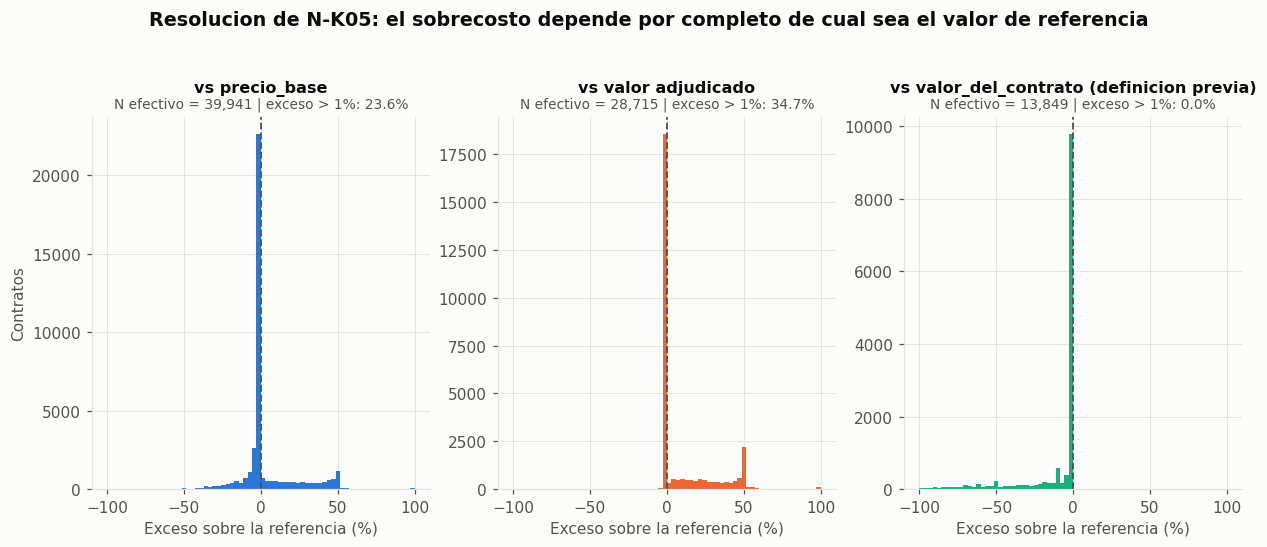

Figura persistida: 05_nk05_referencias_de_valor.png


In [7]:
marcar("fig_nk05")

d1 = df.loc[df["n_contratos_del_portafolio"] == 1]
series = [
    ("vs precio_base", d1["sobrecosto_vs_precio_base_pct"].dropna().clip(-100, 100), PALETA[0]),
    ("vs valor adjudicado", d1["sobrecosto_vs_adjudicado_pct"].dropna().clip(-100, 100), PALETA[1]),
    ("vs valor_del_contrato\n(definicion previa)", d1["desviacion_costo_pct"].dropna().clip(-100, 100), PALETA[2]),
]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4), sharey=False)
for ax, (nombre, v, color) in zip(axes, series):
    ax.hist(v, bins=70, color=color)
    ax.axvline(0, color=TEXT_2, lw=1.2, ls="--")
    pct_pos = (v > 1).mean() * 100
    ax.set_title(f"{nombre.replace(chr(10), ' ')}", fontsize=10.5, pad=16)
    ax.text(0.5, 1.015, f"N efectivo = {len(v):,} | exceso > 1%: {pct_pos:.1f}%",
            transform=ax.transAxes, ha="center", va="bottom", fontsize=9, color=TEXT_2)
    ax.set_xlabel("Exceso sobre la referencia (%)")
    ax.set_axisbelow(True)
axes[0].set_ylabel("Contratos")
fig.suptitle("Resolucion de N-K05: el sobrecosto depende por completo de cual sea el valor de referencia",
             fontsize=12.5, fontweight="bold", y=1.10)
guardar_mostrar(fig, "05_nk05_referencias_de_valor.png")

## 4. Brecha de reporte de pagos frente al valor adjudicado (N-K04)

In [8]:
marcar("nk04")

t = []
for etq, x in [("universo_completo", df), ("observable", obs)]:
    con_adj = x[x["adjudicado_valido"]]
    t.append({
        "lectura": etq, "N": len(x),
        "% valor_pagado == 0": round((x["valor_pagado"] == 0).mean() * 100, 2),
        "N con valor adjudicado utilizable": len(con_adj),
        "% de esos con pago en cero": round((con_adj["valor_pagado"] == 0).mean() * 100, 2),
        "% con pago >= 90% del adjudicado": round(
            (con_adj["valor_pagado"] / con_adj["valor_adjudicado_proceso"] >= 0.9).mean() * 100, 2),
    })
nk04 = pd.DataFrame(t)
print(nk04.to_string(index=False))
print()
print("El proceso registra un valor adjudicado positivo en la mayoria de los contratos que reportan")
print("pago en cero. Es decir: la adjudicacion consta, el contrato consta, y el pago no se reporta.")
print("Es brecha de REPORTE de la ejecucion financiera, no evidencia de que la obra no se pagara.")
print()
print("Tasa de pago en cero por anio de firma (universo completo):")
por_anio = df.groupby("anio_firma").agg(
    n=("id_contrato", "size"),
    pct_pago_cero=("valor_pagado", lambda s: round((s == 0).mean() * 100, 1)))
print(por_anio[por_anio.index.notna()].to_string())

          lectura     N  % valor_pagado == 0  N con valor adjudicado utilizable  % de esos con pago en cero  % con pago >= 90% del adjudicado
universo_completo 48331              68.8900                              35354                     69.1000                           23.9900
       observable 19194              54.7700                              15142                     56.8600                           35.7000

El proceso registra un valor adjudicado positivo en la mayoria de los contratos que reportan
pago en cero. Es decir: la adjudicacion consta, el contrato consta, y el pago no se reporta.
Es brecha de REPORTE de la ejecucion financiera, no evidencia de que la obra no se pagara.

Tasa de pago en cero por anio de firma (universo completo):
               n  pct_pago_cero
anio_firma                     
2,016.0000     7        71.4000
2,017.0000   237        70.0000
2,018.0000  1282        80.7000
2,019.0000  2292        78.8000
2,020.0000  2764        77.9000
2,021.0000 

## 5. Segmentacion por rango de cuantia (brecha 3)

In [9]:
marcar("cuantia")

def perfil_cuantia(x):
    g = x[x["rango_cuantia"].notna()].groupby("rango_cuantia", observed=True)
    r = g.agg(
        n=("id_contrato", "size"),
        n_ef_tiempo=("deslizamiento_plazo_dias", lambda s: int(s.notna().sum())),
        mediana_deslizamiento=("deslizamiento_plazo_dias", "median"),
        pct_retraso_mayor_30=("deslizamiento_plazo_dias", lambda s: round((s.dropna() > 30).mean()*100, 1)),
        n_ef_costo=("desviacion_costo_pct", lambda s: int(s.notna().sum())),
        mediana_costo=("desviacion_costo_pct", "median"),
        pct_no_entregado=("indice_alcance", lambda s: round((s == "No entregado").mean()*100, 1)),
        pct_con_extension=("tiene_extension_dias", lambda s: round(s.mean()*100, 1)),
        mediana_oferentes=("n_oferentes", "median"),
        pct_licitacion=("licitacion_publica", lambda s: round(s.mean()*100, 1)),
        pct_consorcio=("tipo_contratista", lambda s: round((s == "Consorcio / Union Temporal").mean()*100, 1)),
    )
    return r.reindex(ETIQ_CUANTIA)

print("=== UNIVERSO COMPLETO ===")
pc_uni = perfil_cuantia(df); print(pc_uni.to_string())
print()
print("=== SUBCONJUNTO OBSERVABLE ===")
pc_obs = perfil_cuantia(obs); print(pc_obs.to_string())
pc_uni.to_csv(DIR_DATA / "perfil_por_cuantia_universo.csv")
pc_obs.to_csv(DIR_DATA / "perfil_por_cuantia_observable.csv")

=== UNIVERSO COMPLETO ===
                    n  n_ef_tiempo  mediana_deslizamiento  pct_retraso_mayor_30  n_ef_costo  mediana_costo  pct_no_entregado  pct_con_extension  mediana_oferentes  pct_licitacion  pct_consorcio
rango_cuantia                                                                                                                                                                                    
<50M            10800         8281                -1.0000                6.7000        3711         0.0000           14.5000            11.1000             1.0000          0.2000         1.9000
50M-200M        12743        10010                 1.0000               16.6000        3895         0.0000           13.7000            17.7000             1.0000          1.2000         7.6000
200M-1.000M     13051        10388                 1.0000               28.5000        4153        -0.0007            9.3000            26.2000             2.0000         14.3000        24.0000
1.00

                   n  n_ef_tiempo  mediana_deslizamiento  pct_retraso_mayor_30  n_ef_costo  mediana_costo  pct_no_entregado  pct_con_extension  mediana_oferentes  pct_licitacion  pct_consorcio
rango_cuantia                                                                                                                                                                                   
<50M            3617         3202                 0.0000                7.8000        1911         0.0000           35.2000             6.3000             1.0000          0.0000         2.3000
50M-200M        4998         4207                 1.0000               25.9000        2229         0.0000           30.4000            19.3000             1.0000          1.2000         8.1000
200M-1.000M     5750         4903                 4.0000               34.8000        2518        -0.0000           18.2000            21.7000             2.0000         14.6000        24.2000
1.000M-10.000M  3963         3263  

In [10]:
marcar("cuantia_pruebas")

sub = obs[obs["rango_cuantia"].notna()]
for var, nombre in [("deslizamiento_plazo_dias", "deslizamiento del plazo"),
                    ("desviacion_costo_pct", "desviacion de costo")]:
    g = {k: v[var].dropna() for k, v in sub.groupby("rango_cuantia", observed=True)}
    kw = kruskal(g)
    print(f"Kruskal-Wallis, {nombre} entre rangos de cuantia (observable):")
    print(" ", resumen_prueba(kw)); print()

tab = pd.crosstab(sub["rango_cuantia"], sub["indice_alcance"])
print("Chi-cuadrado, rango de cuantia x indice de alcance (observable):")
print(" ", resumen_prueba(cramers_v(tab)))
print()
sp = spearman(obs["valor_del_contrato"], obs["deslizamiento_plazo_dias"])
print(f"Spearman valor ~ deslizamiento (observable): rho = {sp['rho']:.3f}, N efectivo = {sp['n_efectivo']:,} ({sp['efecto']})")
sp = spearman(obs["valor_del_contrato"], obs["desviacion_costo_pct"])
print(f"Spearman valor ~ desviacion de costo (observable): rho = {sp['rho']:.3f}, N efectivo = {sp['n_efectivo']:,} ({sp['efecto']})")

Kruskal-Wallis, deslizamiento del plazo entre rangos de cuantia (observable):
  H = 2,272.15 | gl = 4 | p = < 1e-300 | epsilon2 = 0.1390 (moderado) | k = 5 grupos | N efectivo = 16,326

Kruskal-Wallis, desviacion de costo entre rangos de cuantia (observable):
  H = 1,225.28 | gl = 4 | p = 5.26e-264 | epsilon2 = 0.1408 (moderado) | k = 5 grupos | N efectivo = 8,681

Chi-cuadrado, rango de cuantia x indice de alcance (observable):
  chi2 = 2,301.81 | gl = 8 | p = < 1e-300 | V de Cramer = 0.245 (debil-moderado) | N efectivo = 19,194 | minima frecuencia esperada = 176.4

Spearman valor ~ deslizamiento (observable): rho = 0.379, N efectivo = 16,326 (mediano)
Spearman valor ~ desviacion de costo (observable): rho = -0.359, N efectivo = 8,681 (mediano)


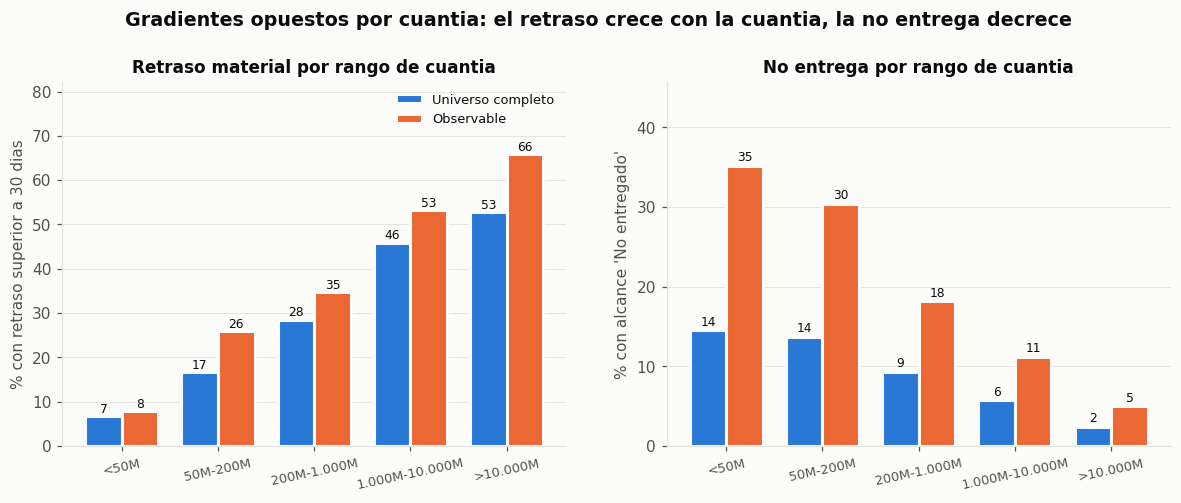

Figura persistida: 05_gradiente_por_cuantia.png


In [11]:
marcar("fig_cuantia")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
x = np.arange(len(ETIQ_CUANTIA)); w = 0.38

ax = axes[0]
ax.bar(x - w/2, pc_uni["pct_retraso_mayor_30"], w, label="Universo completo",
       color=PALETA[0], edgecolor=SURFACE, linewidth=2)
ax.bar(x + w/2, pc_obs["pct_retraso_mayor_30"], w, label="Observable",
       color=PALETA[1], edgecolor=SURFACE, linewidth=2)
for i, (a, b) in enumerate(zip(pc_uni["pct_retraso_mayor_30"], pc_obs["pct_retraso_mayor_30"])):
    ax.text(i - w/2, a + 0.8, f"{a:.0f}", ha="center", fontsize=8, color=TEXT_1)
    ax.text(i + w/2, b + 0.8, f"{b:.0f}", ha="center", fontsize=8, color=TEXT_1)
ax.set_xticks(x); ax.set_xticklabels(ETIQ_CUANTIA, fontsize=8.5, rotation=12)
ax.set_ylabel("% con retraso superior a 30 dias")
ax.set_ylim(0, max(pc_obs["pct_retraso_mayor_30"].max(), pc_uni["pct_retraso_mayor_30"].max()) * 1.25)
ax.set_title("Retraso material por rango de cuantia", fontsize=11)
ax.legend(fontsize=8.5); ax.xaxis.grid(False); ax.set_axisbelow(True)

ax = axes[1]
ax.bar(x - w/2, pc_uni["pct_no_entregado"], w, color=PALETA[0], edgecolor=SURFACE, linewidth=2)
ax.bar(x + w/2, pc_obs["pct_no_entregado"], w, color=PALETA[1], edgecolor=SURFACE, linewidth=2)
for i, (a, b) in enumerate(zip(pc_uni["pct_no_entregado"], pc_obs["pct_no_entregado"])):
    ax.text(i - w/2, a + 0.6, f"{a:.0f}", ha="center", fontsize=8, color=TEXT_1)
    ax.text(i + w/2, b + 0.6, f"{b:.0f}", ha="center", fontsize=8, color=TEXT_1)
ax.set_xticks(x); ax.set_xticklabels(ETIQ_CUANTIA, fontsize=8.5, rotation=12)
ax.set_ylabel("% con alcance 'No entregado'")
ax.set_ylim(0, max(pc_obs["pct_no_entregado"].max(), pc_uni["pct_no_entregado"].max()) * 1.3)
ax.set_title("No entrega por rango de cuantia", fontsize=11)
ax.xaxis.grid(False); ax.set_axisbelow(True)

fig.suptitle("Gradientes opuestos por cuantia: el retraso crece con la cuantia, la no entrega decrece",
             fontsize=12.5, fontweight="bold", y=1.03)
guardar_mostrar(fig, "05_gradiente_por_cuantia.png")

## 6. Persistencia y sintesis de hallazgos etiquetados

In [12]:
df[["id_contrato", "sobrecosto_vs_precio_base_pct", "sobrecosto_vs_adjudicado_pct",
    "adjudicado_valido", "n_contratos_del_portafolio"]].to_parquet(
    DIR_DATA / "sobrecosto_referencias.parquet", index=False)

reg = RegistroHallazgos("05")
reg.add("H05-01",
        "N-K05 RESUELTO: el sobrecosto contra el presupuesto oficial del proceso es del orden del 24%, frente al 0.1% medido contra valor_del_contrato",
        f"1 contrato por proceso: {pb_1pct:.2f}% supera precio_base en mas del 1%; {adj_1pct:.2f}% supera el valor adjudicado; {ant_1pct:.2f}% con la definicion previa",
        ref("nk05_veredicto"), ["A-OE03", "B-OE2", "CALIDAD"], "Alto",
        "Confirma que `valor_del_contrato` es el valor vigente tras adiciones y no el inicial pactado; concilia la medicion con el planteamiento del problema")
reg.add("H05-02",
        "El exceso sobre el precio base es mayor en los contratos con adicion de valor registrada, lo que confirma el mecanismo propuesto",
        "Mann-Whitney con tamano de efecto reportado en la celda de veredicto", ref("nk05_veredicto"),
        ["A-OE03", "B-OE3-insumo"], "Alto",
        "Evidencia de mecanismo, no solo de magnitud")
reg.add("H05-03",
        "Los contratos con pago en cero tienen valor adjudicado positivo en el proceso: la brecha es de reporte de ejecucion financiera",
        "Tabla de contraste pago frente a valor adjudicado, en doble lectura", ref("nk04"),
        ["CALIDAD", "B-OE2"], "Alto", "Cierra N-K04 con evidencia de una segunda fuente")
reg.add("H05-04",
        "El retraso material crece monotonicamente con la cuantia, pero la NO ENTREGA se comporta al reves: decrece al subir la cuantia",
        "Perfil por rango de cuantia en doble lectura: retraso > 30 dias sube del rango bajo al alto; alcance 'No entregado' baja",
        ref("cuantia_pruebas"), ["A-OE04", "A-H1", "B-OE2", "B-OE3-insumo"], "Alto",
        "Cierra la brecha 3. El gradiente opuesto de las dos dimensiones desaconseja hablar de 'peor desempeno' sin especificar la dimension")
reg.add("H05-05",
        "La cuantia y la modalidad estan fuertemente asociadas: la licitacion publica se concentra en los rangos altos",
        "Columna pct_licitacion del perfil por cuantia", ref("cuantia"),
        ["A-H1", "B-OE2"], "Alto",
        "Es la confusion que obliga a estratificar A-H1 por cuantia en el notebook 10")
reg.add("H05-06",
        "`precio_base` y `valor_del_contrato` correlacionan fuerte pero no perfectamente, lo que hace del primero una referencia inicial utilizable",
        "Matriz de Spearman entre las cuatro magnitudes monetarias", ref("corr_valores"),
        ["A-OE03", "B-OE3-insumo"], "Medio",
        "Si la correlacion fuese 1 el contraste de N-K05 seria vacuo")
reg.guardar()
reg.tabla()

,id,notebook,celda,hallazgo,evidencia,etiquetas,valor,nota
0,H05-01,05,c007,N-K05 RESUELTO: el sobrecosto contra el presup...,1 contrato por proceso: 23.60% supera precio_b...,[A-OE03] [B-OE2] [CALIDAD],Alto,Confirma que `valor_del_contrato` es el valor ...
1,H05-02,05,c007,El exceso sobre el precio base es mayor en los...,Mann-Whitney con tamano de efecto reportado en...,[A-OE03] [B-OE3-insumo],Alto,"Evidencia de mecanismo, no solo de magnitud"
2,H05-03,05,c009,Los contratos con pago en cero tienen valor ad...,Tabla de contraste pago frente a valor adjudic...,[CALIDAD] [B-OE2],Alto,Cierra N-K04 con evidencia de una segunda fuente
3,H05-04,05,c011,El retraso material crece monotonicamente con ...,Perfil por rango de cuantia en doble lectura: ...,[A-OE04] [A-H1] [B-OE2] [B-OE3-insumo],Alto,Cierra la brecha 3. El gradiente opuesto de la...
4,H05-05,05,c010,La cuantia y la modalidad estan fuertemente as...,Columna pct_licitacion del perfil por cuantia,[A-H1] [B-OE2],Alto,Es la confusion que obliga a estratificar A-H1...
5,H05-06,05,c005,`precio_base` y `valor_del_contrato` correlaci...,Matriz de Spearman entre las cuatro magnitudes...,[A-OE03] [B-OE3-insumo],Medio,Si la correlacion fuese 1 el contraste de N-K0...


## Sintesis del notebook 05

| ID | Hallazgo | Etiquetas |
|---|---|---|
| H05-01 | **N-K05 resuelto**: el sobrecosto contra el presupuesto oficial del proceso es del orden del 24%, no del 0,1% | `[A-OE03]` `[B-OE2]` `[CALIDAD]` |
| H05-02 | El exceso sobre el precio base es mayor donde hay adicion de valor registrada: evidencia de mecanismo | `[A-OE03]` `[B-OE3-insumo]` |
| H05-03 | Los contratos con pago en cero tienen valor adjudicado positivo: brecha de reporte financiero | `[CALIDAD]` `[B-OE2]` |
| H05-04 | El retraso material crece con la cuantia pero la no entrega decrece: gradientes opuestos por dimension | `[A-OE04]` `[A-H1]` `[B-OE2]` `[B-OE3-insumo]` |
| H05-05 | Cuantia y modalidad estan fuertemente asociadas: obliga a estratificar A-H1 | `[A-H1]` `[B-OE2]` |
| H05-06 | `precio_base` correlaciona fuerte pero no perfectamente con `valor_del_contrato` | `[A-OE03]` `[B-OE3-insumo]` |

**Productos persistidos:** `data/nk05_sobrecosto_referencias.csv`,
`data/sobrecosto_referencias.parquet`, `data/perfil_por_cuantia_universo.csv`,
`data/perfil_por_cuantia_observable.csv`, `figuras/05_nk05_referencias_de_valor.png`,
`figuras/05_gradiente_por_cuantia.png`.

**Limitaciones declaradas del contraste de N-K05.**

1. `precio_base` es un presupuesto estimado, no un valor pactado. Un exceso sobre el presupuesto puede
   deberse a una adjudicacion por encima del estimado y no a una adicion posterior. La lectura contra
   `valor_total_adjudicacion` corrige ese sesgo y arroja una magnitud aun mayor.
2. Cuando un portafolio agrupa varios contratos, el valor adjudicado del proceso no es comparable con
   el valor de un contrato individual. Por eso la lectura titular se restringe a procesos con un unico
   contrato, y se reportan las cuatro lecturas para que el sesgo sea auditable.
3. Ninguna de las magnitudes esta deflactada. Las comparaciones son en pesos corrientes dentro de cada
   contrato, lo que es correcto porque el presupuesto, la adjudicacion y el valor contractual pertenecen
   al mismo proceso; no lo seria para comparar cuantias entre anios.